# Visualizaciones del Proyecto de Predicción Logística

Este notebook genera visualizaciones del forecast Prophet para 7 categorías de productos,
combinando datos históricos con predicciones a 90 días e intervalos de confianza.

## 1. Configuración Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de Datos

In [2]:
# Cargar datos históricos y forecast
hist = pd.read_csv('./clean_data.csv')
fc = pd.read_csv('./forecast_consolidado_90d.csv')

# Convertir fechas
hist['fecha'] = pd.to_datetime(hist['fecha'])
fc['fecha'] = pd.to_datetime(fc['fecha'])

print(f'Histórico: {len(hist)} transacciones, {hist["fecha"].nunique()} días')
print(f'Forecast: {len(fc)} filas, {fc["fecha"].nunique()} días')
print(f'Categorías en forecast: {sorted(fc["categoria"].unique())}')

Histórico: 22640 transacciones, 603 días
Forecast: 637 filas, 91 días
Categorías en forecast: ['Bebidas', 'Carnes', 'Congelados', 'Descartables', 'Embutidos', 'Enlatados', 'Lácteos']


## 3. Preprocesamiento

In [3]:
# Unificar nombres de categorías: histórico usa tilde, forecast no
cat_map = {
    'Lácteos': 'Lacteos', 'Lacteos': 'Lacteos',
    'Descartables': 'Descartables',
    'Carnes': 'Carnes',
    'Bebidas': 'Bebidas',
    'Enlatados': 'Enlatados',
    'Embutidos': 'Embutidos',
    'Congelados': 'Congelados'
}
hist['categoria'] = hist['categoria'].replace(cat_map)
fc['categoria'] = fc['categoria'].replace(cat_map)

# Verificar que coincidan
hist_cats = sorted(hist['categoria'].unique())
fc_cats = sorted(fc['categoria'].unique())
print('Histórico categorías:', hist_cats)
print('Forecast categorías:', fc_cats)
assert hist_cats == fc_cats, '¡Las categorías no coinciden!'

# Agregar histórico a frecuencia diaria por categoría
hist_daily = hist.groupby(['fecha', 'categoria'], as_index=False)['cantidad'].sum()

CATEGORIAS = hist_cats
palette = sns.color_palette('husl', len(CATEGORIAS))
cat_colors = dict(zip(CATEGORIAS, palette))

print(f'\n{len(CATEGORIAS)} categorías listas: {CATEGORIAS}')
print(f'Histórico: {hist_daily["fecha"].min().date()} a {hist_daily["fecha"].max().date()}')
print(f'Forecast:  {fc["fecha"].min().date()} a {fc["fecha"].max().date()}')

Histórico categorías: ['Bebidas', 'Carnes', 'Congelados', 'Descartables', 'Embutidos', 'Enlatados', 'Lacteos']
Forecast categorías: ['Bebidas', 'Carnes', 'Congelados', 'Descartables', 'Embutidos', 'Enlatados', 'Lacteos']

7 categorías listas: ['Bebidas', 'Carnes', 'Congelados', 'Descartables', 'Embutidos', 'Enlatados', 'Lacteos']
Histórico: 2023-01-03 a 2024-12-11
Forecast:  2024-12-12 a 2025-03-12


---
## V1 — Serie Temporal Completa: Histórico + Forecast (Facetado 4×2)

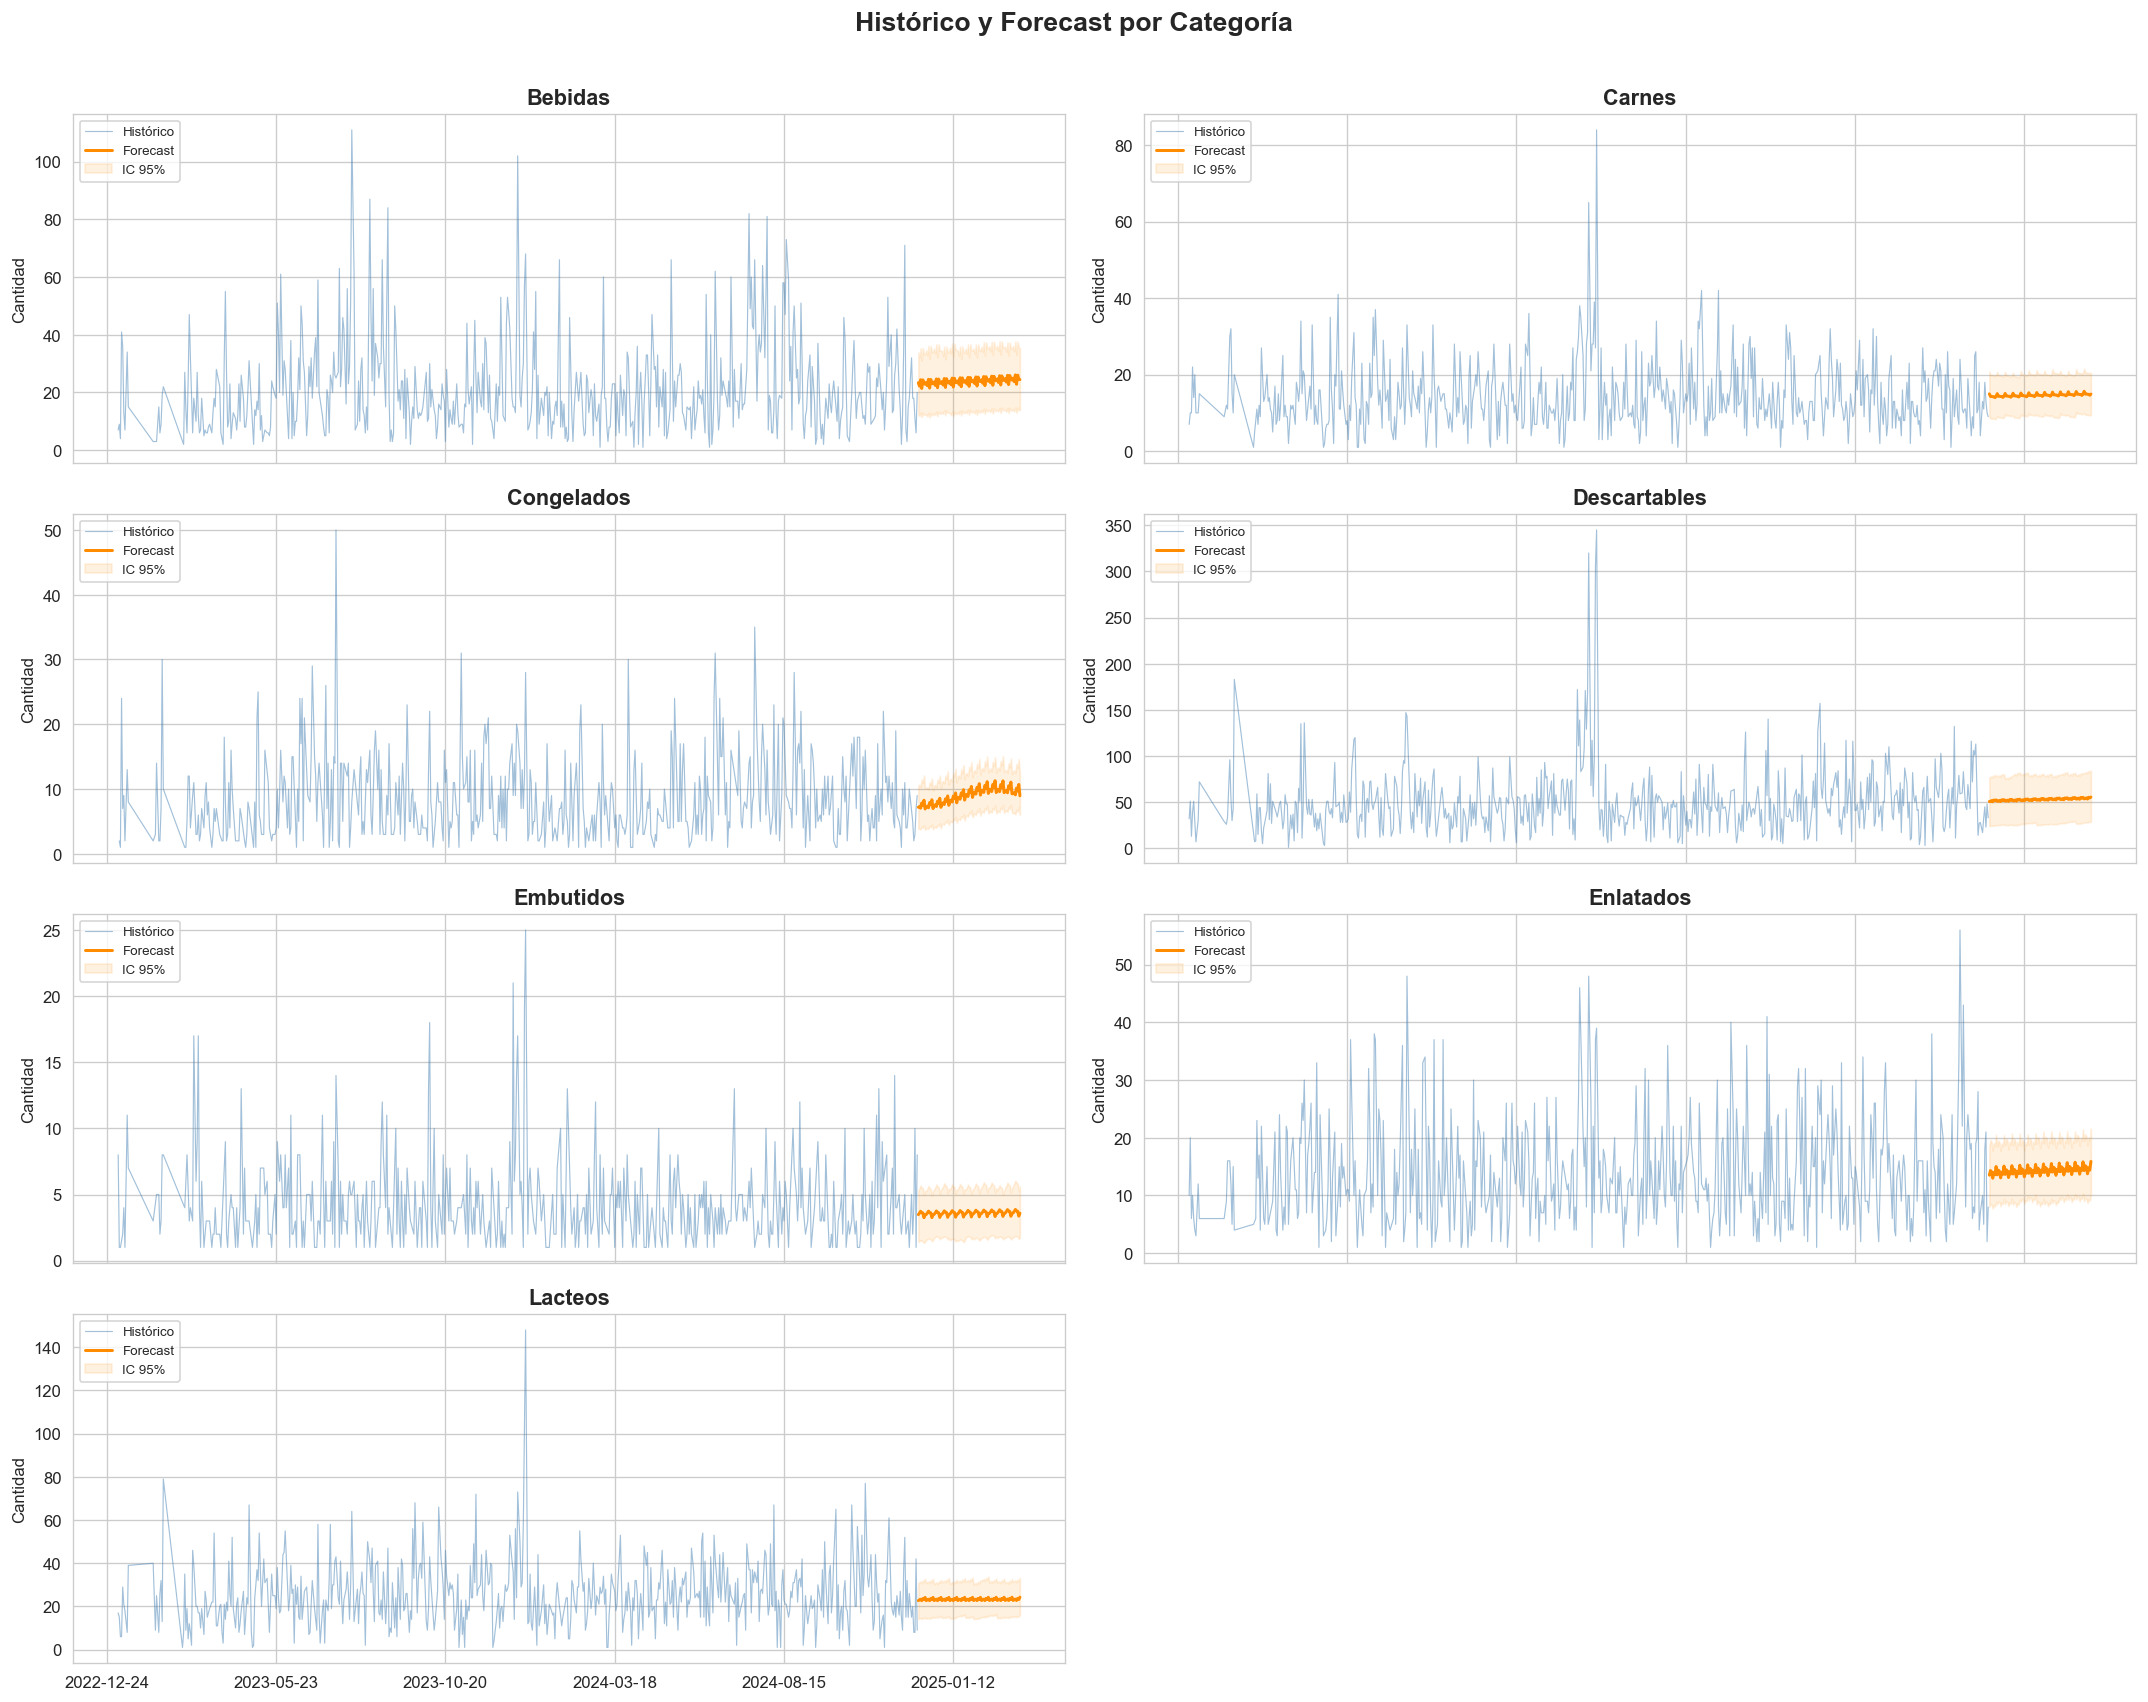

Gráfico guardado: viz_01_historico_forecast.png


In [4]:
fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True)
axes = axes.flatten()
fig.suptitle('Histórico y Forecast por Categoría', fontsize=16, fontweight='bold', y=1.01)

for i, cat in enumerate(CATEGORIAS):
    ax = axes[i]
    h = hist_daily[hist_daily['categoria'] == cat].set_index('fecha')
    f = fc[fc['categoria'] == cat].set_index('fecha')

    ax.plot(h.index, h['cantidad'], color='steelblue', alpha=0.5, lw=0.7, label='Histórico')
    ax.plot(f.index, f['cantidad_forecast'], color='darkorange', lw=1.8, label='Forecast')
    ax.fill_between(f.index, f['ci_lower'], f['ci_upper'],
                    color='darkorange', alpha=0.12, label='IC 95%')

    ax.set_title(cat, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.set_ylabel('Cantidad')

# Ocultar el último subplot vacío
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('./viz_01_historico_forecast.png')
plt.show()
print('Gráfico guardado: viz_01_historico_forecast.png')

---
## V2 — Comparación de Forecast (todas las categorías en un solo chart)

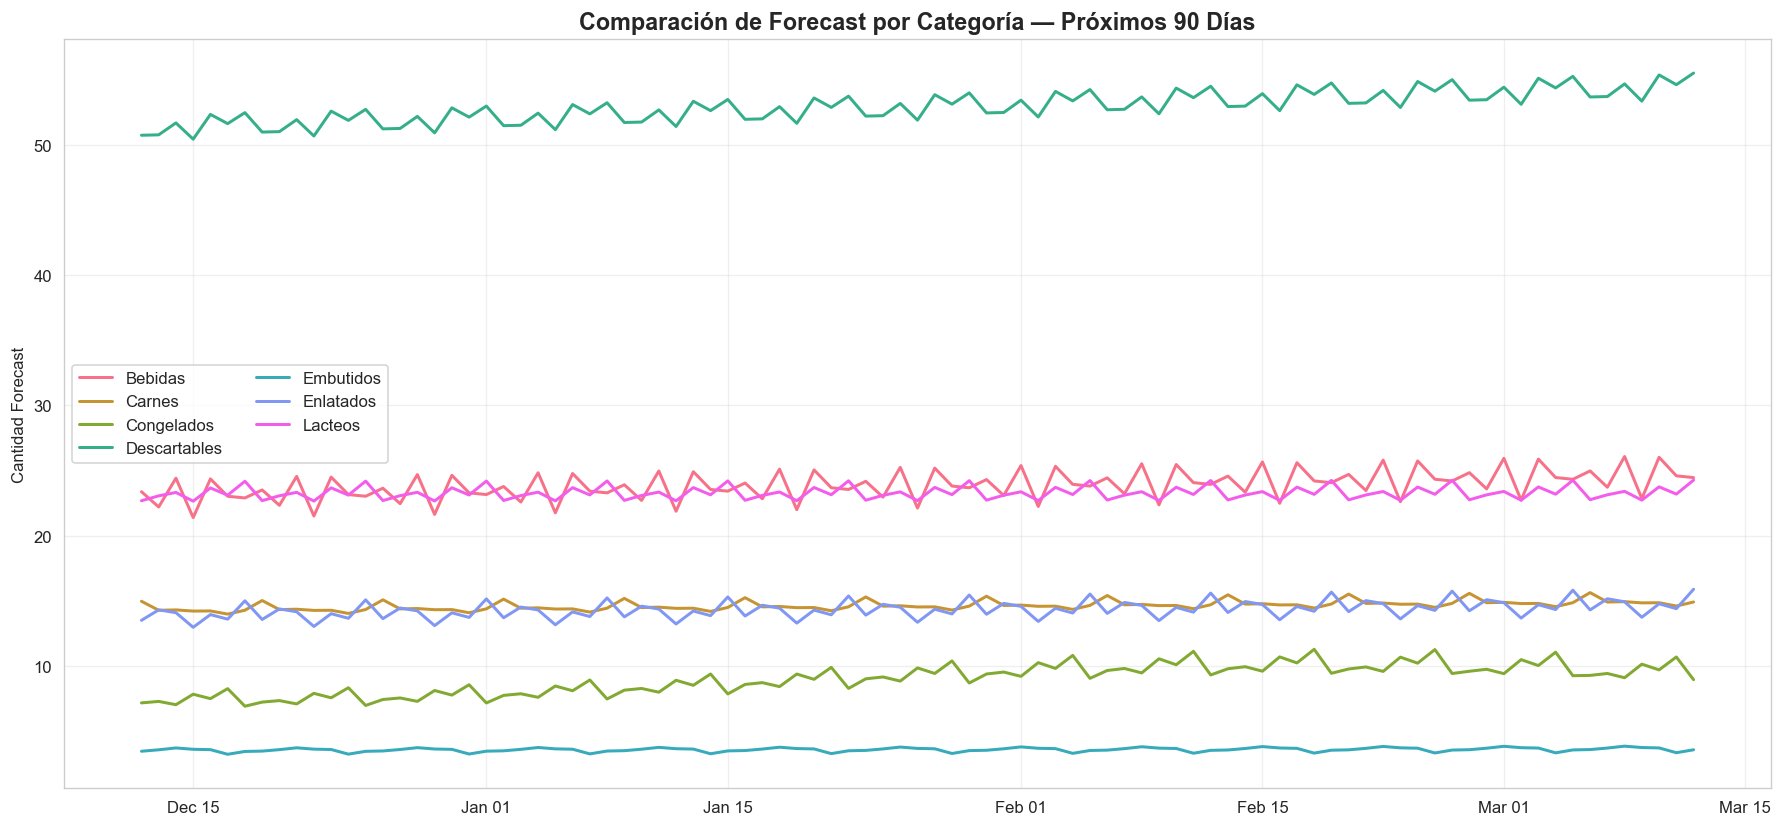

Gráfico guardado: viz_02_comparacion_forecast.png


In [5]:
fig, ax = plt.subplots(figsize=(15, 7))

for cat in CATEGORIAS:
    f = fc[fc['categoria'] == cat].set_index('fecha')
    ax.plot(f.index, f['cantidad_forecast'], color=cat_colors[cat],
            lw=1.8, label=cat)

ax.set_title('Comparación de Forecast por Categoría — Próximos 90 Días',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.set_ylabel('Cantidad Forecast')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./viz_02_comparacion_forecast.png')
plt.show()
print('Gráfico guardado: viz_02_comparacion_forecast.png')

---
## V3 — Total 90 Días por Categoría (barras horizontales)

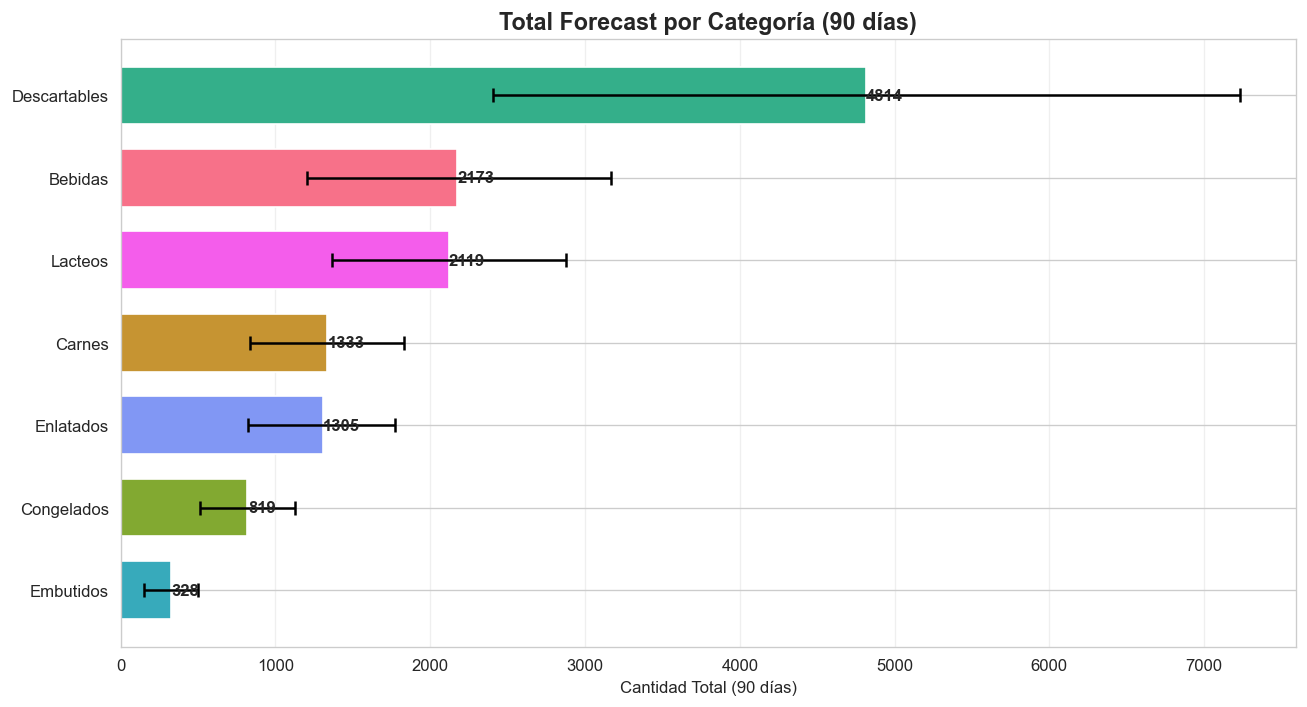

Gráfico guardado: viz_03_total_90d_barras.png


In [6]:
totals = fc.groupby('categoria')['cantidad_forecast'].sum().sort_values(ascending=True)
ci_low = fc.groupby('categoria')['ci_lower'].sum()
ci_high = fc.groupby('categoria')['ci_upper'].sum()

fig, ax = plt.subplots(figsize=(11, 6))

colors_bars = [cat_colors[c] for c in totals.index]
ax.barh(totals.index, totals.values, color=colors_bars, edgecolor='white', height=0.7)
ax.errorbar(totals.values, range(len(totals)),
            xerr=[totals.values - ci_low[totals.index], ci_high[totals.index] - totals.values],
            fmt='none', ecolor='black', capsize=4, capthick=1.5)

for i, (cat, val) in enumerate(totals.items()):
    ax.text(val + 3, i, f'{val:.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Total Forecast por Categoría (90 días)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad Total (90 días)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('./viz_03_total_90d_barras.png')
plt.show()
print('Gráfico guardado: viz_03_total_90d_barras.png')

---
## V4 — Tendencia Semanal del Forecast

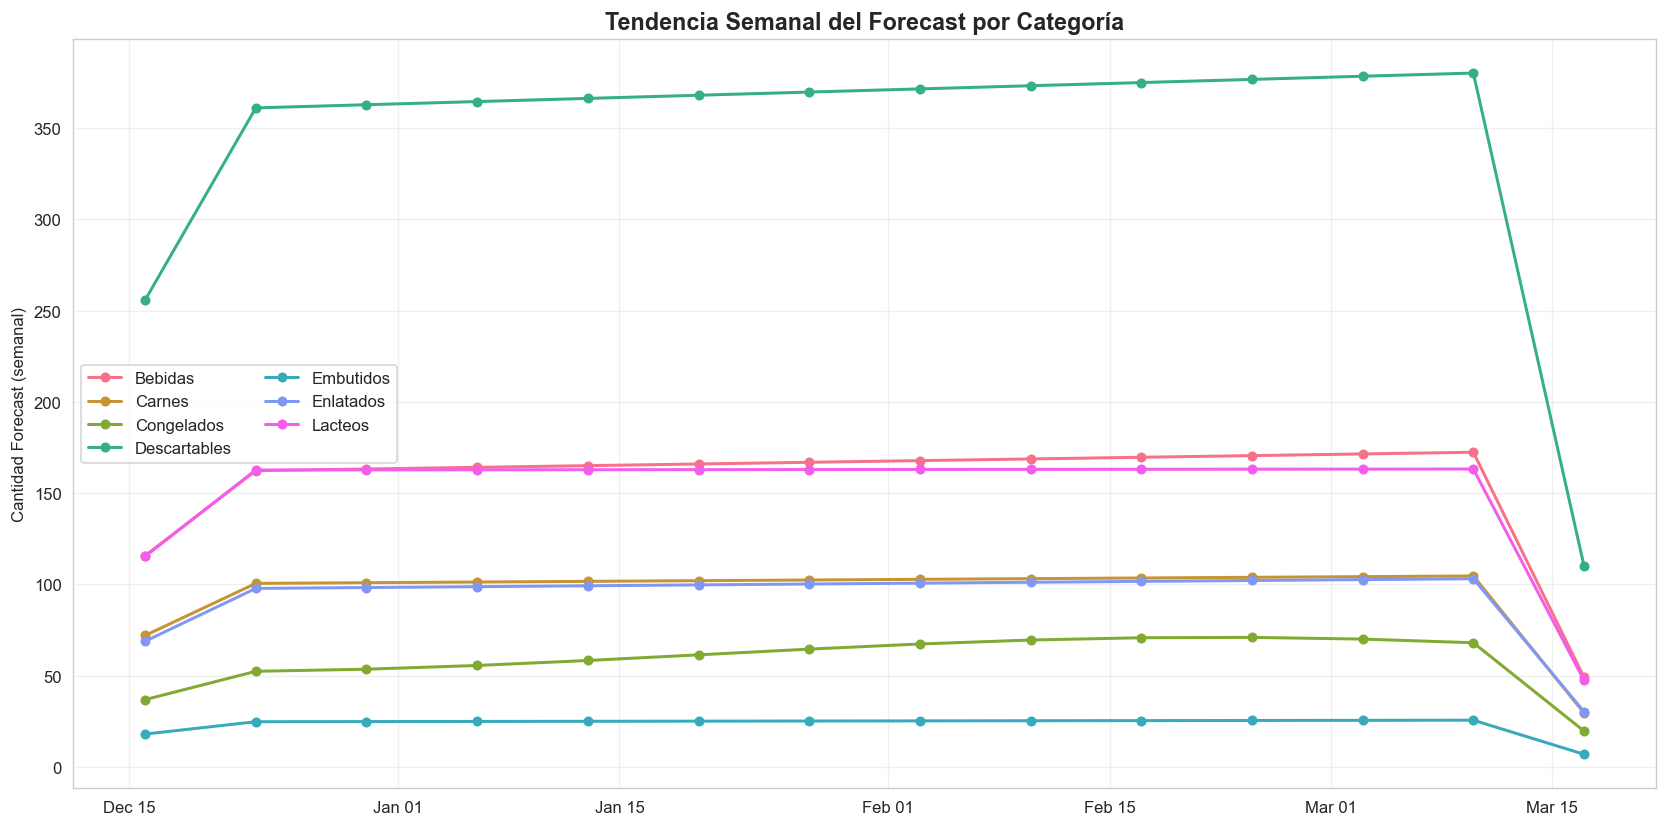

Gráfico guardado: viz_04_tendencia_semanal.png


In [7]:
# Agregar por semana
fc_week = fc.copy()
fc_week = (fc_week.set_index('fecha')
           .groupby('categoria')
           .resample('W-MON')['cantidad_forecast']
           .sum()
           .reset_index())

fig, ax = plt.subplots(figsize=(14, 7))

for cat in CATEGORIAS:
    cw = fc_week[fc_week['categoria'] == cat]
    ax.plot(cw['fecha'], cw['cantidad_forecast'],
            color=cat_colors[cat], marker='o', markersize=5, lw=1.8, label=cat)

ax.set_title('Tendencia Semanal del Forecast por Categoría', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.set_ylabel('Cantidad Forecast (semanal)')
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./viz_04_tendencia_semanal.png')
plt.show()
print('Gráfico guardado: viz_04_tendencia_semanal.png')

---
## V5 — Incertidumbre del Forecast (Ancho Promedio del IC)

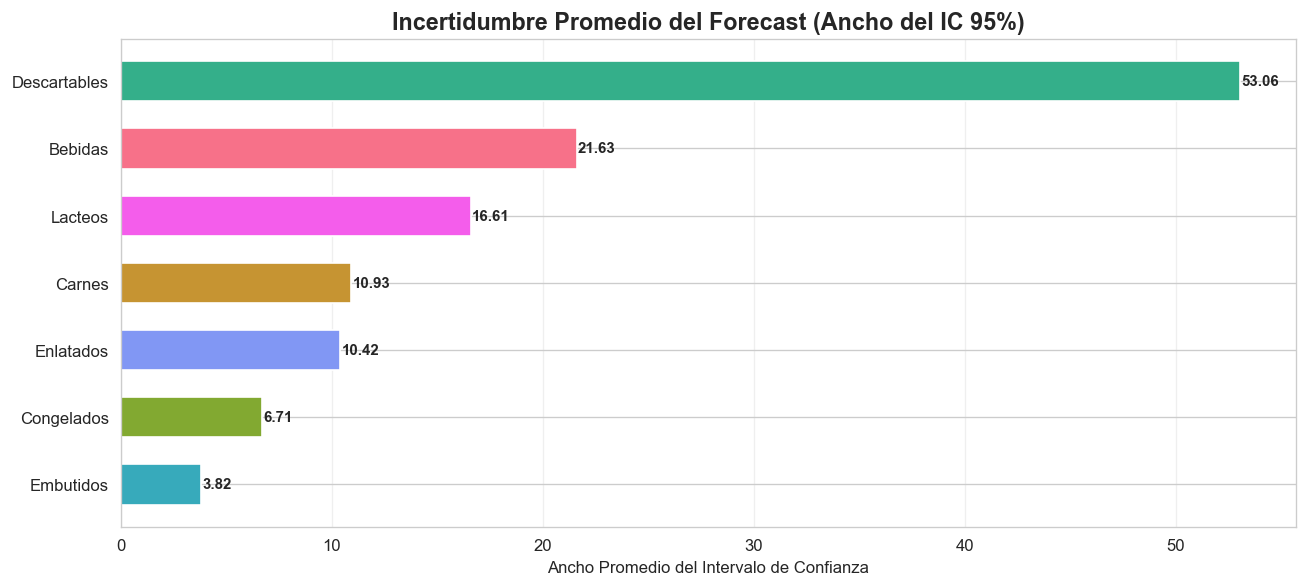

Gráfico guardado: viz_05_incertidumbre.png


In [8]:
fc['ci_width'] = fc['ci_upper'] - fc['ci_lower']
uncertainty = fc.groupby('categoria')['ci_width'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))

colors_unc = [cat_colors[c] for c in uncertainty.index]
ax.barh(uncertainty.index, uncertainty.values, color=colors_unc, edgecolor='white', height=0.6)

for i, (cat, val) in enumerate(uncertainty.items()):
    ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Incertidumbre Promedio del Forecast (Ancho del IC 95%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ancho Promedio del Intervalo de Confianza')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('./viz_05_incertidumbre.png')
plt.show()
print('Gráfico guardado: viz_05_incertidumbre.png')

---
## V6 — Forecast Consolidado Diario (Suma de Todas las Categorías)

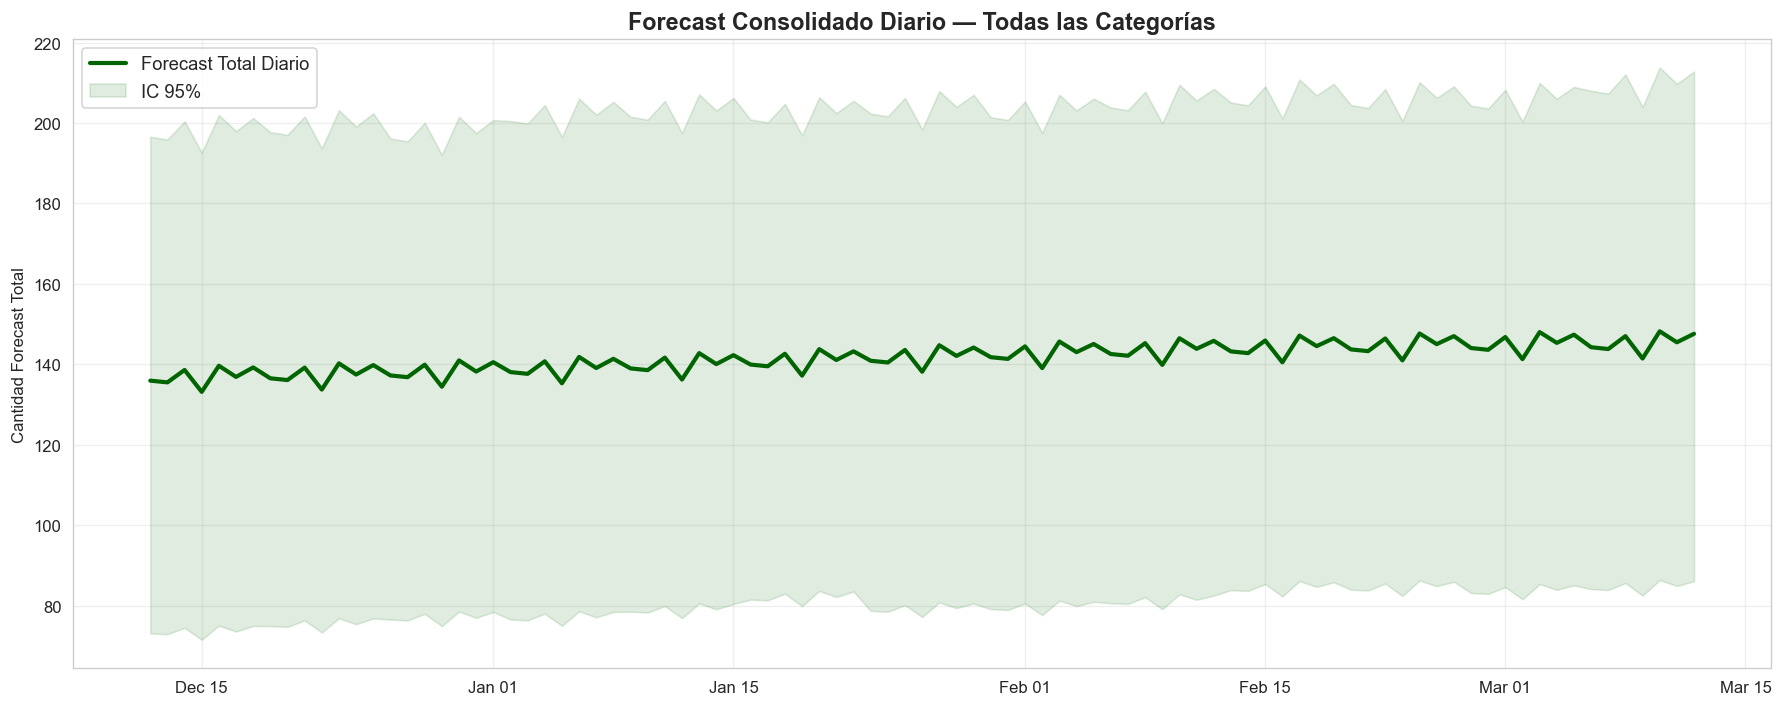

Gráfico guardado: viz_06_consolidado_diario.png


In [9]:
consolidado = fc.groupby('fecha').agg({
    'cantidad_forecast': 'sum',
    'ci_lower': 'sum',
    'ci_upper': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(consolidado['fecha'], consolidado['cantidad_forecast'],
        color='darkgreen', lw=2.5, label='Forecast Total Diario')
ax.fill_between(consolidado['fecha'], consolidado['ci_lower'], consolidado['ci_upper'],
                color='darkgreen', alpha=0.12, label='IC 95%')

ax.set_title('Forecast Consolidado Diario — Todas las Categorías',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad Forecast Total')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./viz_06_consolidado_diario.png')
plt.show()
print('Gráfico guardado: viz_06_consolidado_diario.png')

---
## V7 — Tabla Resumen del Forecast

In [10]:
summary = fc.groupby('categoria').agg(
    Total=('cantidad_forecast', 'sum'),
    Media_Diaria=('cantidad_forecast', 'mean'),
    Min_Diario=('cantidad_forecast', 'min'),
    Max_Diario=('cantidad_forecast', 'max'),
    IC_Medio=('ci_width', 'mean')
).round(2).sort_values('Total', ascending=False)

print(summary)

# Guardar tabla como CSV
summary.to_csv('./resumen_forecast_categorias.csv')
print('\nTabla guardada: resumen_forecast_categorias.csv')

                Total  Media_Diaria  Min_Diario  Max_Diario  IC_Medio
categoria                                                            
Descartables  4813.80         52.90       50.41       55.48     53.06
Bebidas       2173.50         23.88       21.40       26.08     21.63
Lacteos       2118.68         23.28       22.65       24.27     16.61
Carnes        1333.07         14.65       13.99       15.64     10.93
Enlatados     1304.99         14.34       12.98       15.90     10.42
Congelados     819.39          9.00        6.93       11.29      6.71
Embutidos      327.51          3.60        3.25        3.87      3.82

Tabla guardada: resumen_forecast_categorias.csv


---
## V8 — Descomposición Semanal: Forecast por Día de la Semana

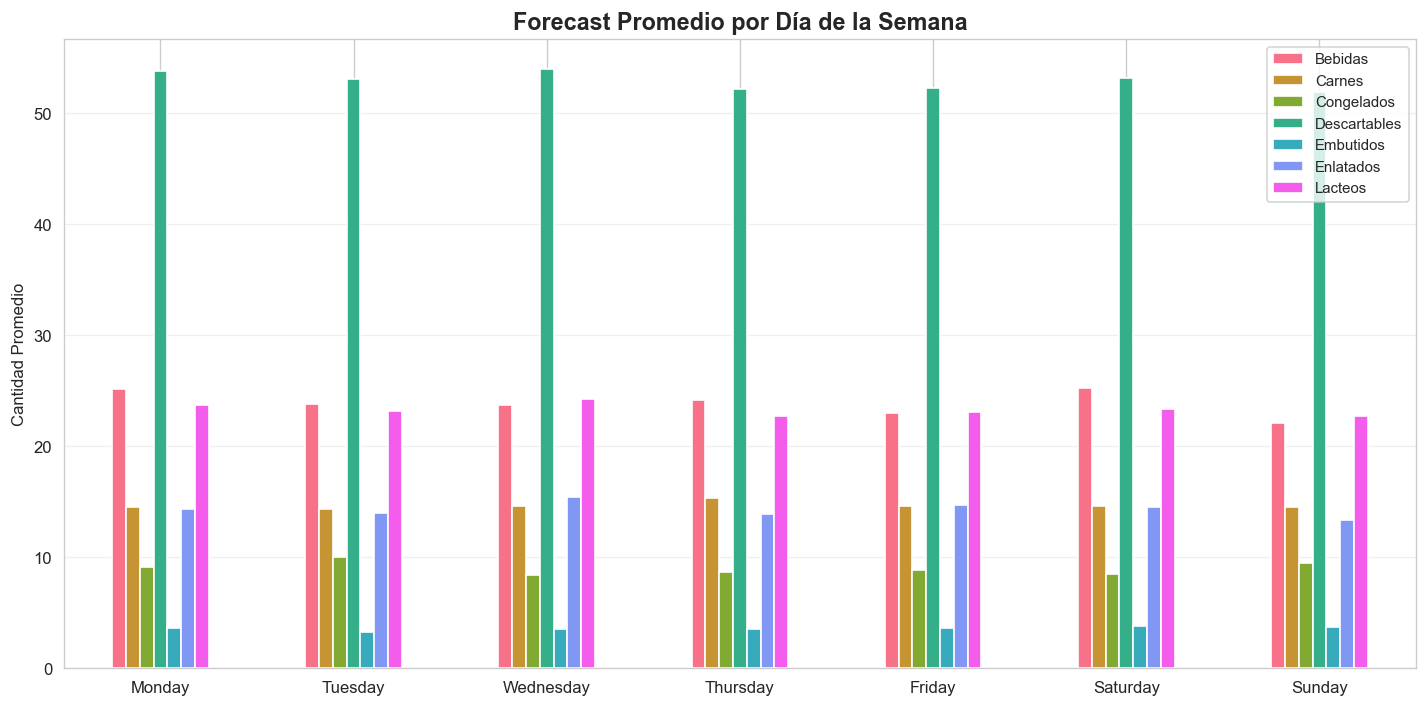

Gráfico guardado: viz_07_forecast_dia_semana.png


In [11]:
fc_dow = fc.copy()
fc_dow['dia_semana'] = fc_dow['fecha'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot_dow = fc_dow.pivot_table(
    index='dia_semana', columns='categoria',
    values='cantidad_forecast', aggfunc='mean'
).reindex(order)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_dow.plot(kind='bar', ax=ax, color=[cat_colors[c] for c in pivot_dow.columns], edgecolor='white')
ax.set_title('Forecast Promedio por Día de la Semana', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad Promedio')
ax.set_xlabel('')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./viz_07_forecast_dia_semana.png')
plt.show()
print('Gráfico guardado: viz_07_forecast_dia_semana.png')

---
## V9 — Distribución del Forecast por Categoría (Boxplot)

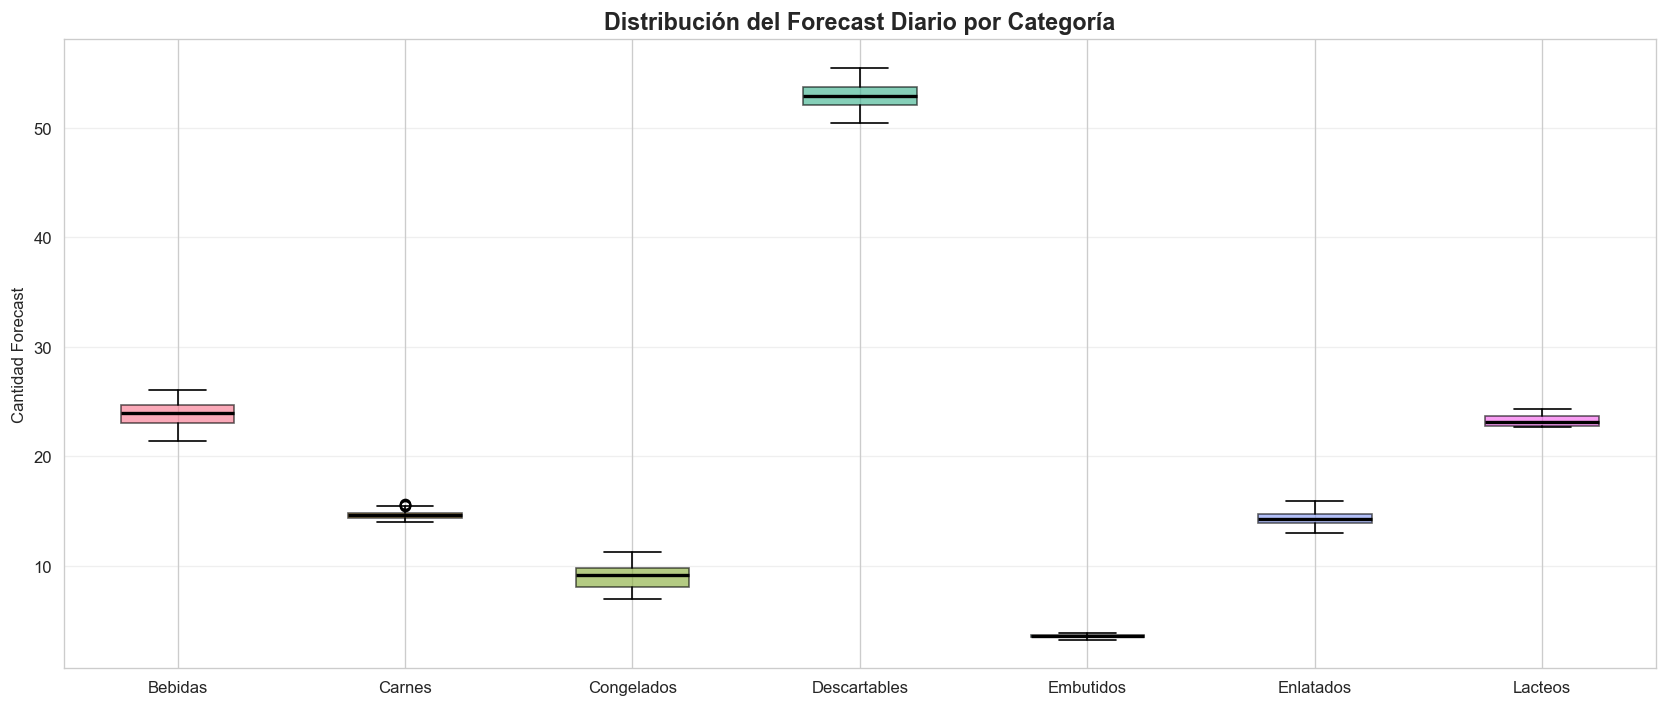

Gráfico guardado: viz_08_distribucion_forecast.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
bp_data = [fc[fc['categoria'] == cat]['cantidad_forecast'].values for cat in CATEGORIAS]
bp = ax.boxplot(bp_data, labels=CATEGORIAS, patch_artist=True,
                medianprops=dict(color='black', lw=2))

for patch, color in zip(bp['boxes'], [cat_colors[c] for c in CATEGORIAS]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('Distribución del Forecast Diario por Categoría', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad Forecast')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./viz_08_distribucion_forecast.png')
plt.show()
print('Gráfico guardado: viz_08_distribucion_forecast.png')

---
## Fin del Reporte de Visualizaciones

In [13]:
print('\n' + '='*60)
print('TODAS LAS VISUALIZACIONES GENERADAS')
print('='*60)
print('Archivos PNG creados:')
import glob
for f in sorted(glob.glob('./viz_*.png')):
    print(f'  • {f}')
print(f'\nCSV resumen: resumen_forecast_categorias.csv')


TODAS LAS VISUALIZACIONES GENERADAS
Archivos PNG creados:
  • .\viz_01_historico_forecast.png
  • .\viz_02_comparacion_forecast.png
  • .\viz_03_total_90d_barras.png
  • .\viz_04_tendencia_semanal.png
  • .\viz_05_incertidumbre.png
  • .\viz_06_consolidado_diario.png
  • .\viz_07_forecast_dia_semana.png
  • .\viz_08_distribucion_forecast.png

CSV resumen: resumen_forecast_categorias.csv
